<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_3_MNIST_Dataset_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 3 - MNIST Dataset with PyTorch
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [ ]:
# Import necessary packages
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time

In [ ]:
import os
from google.colab import drive

###**Step 1: Define The Transforms & Download The Dataset**
Before downloading the data, let us define what are the transformations we want to perform on our data before feeding it into the pipeline. In other words, you can consider it to be some kind of custom edit to are performing to the images so that all the images have the same dimensions and properties. We do it using **torchvision.transforms**.


In [ ]:
from torchvision import datasets, transforms

***transforms.ToTensor( )*** — converts the image into numbers, that are understandable by the system. It separates the image into three color channels (separate images): red, green & blue. Then it converts the pixels of each image to the brightness of their color between 0 and 255. These values are then scaled down to a range between 0 and 1. The image is now a Torch Tensor.

***transforms.Normalize( )*** — normalizes the tensor with a mean and standard deviation which goes as the two parameters respectively.

In [ ]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])

Now we finally download the data sets, shuffle them and transform each of them. We download the data sets and load them to *DataLoader*, which combines the data-set and a sampler and provides single- or multi-process iterators over the data-set.

In [ ]:
# Download and load the training data
trainset = datasets.MNIST('drive/My Drive/mnist/MNIST_data/', download=True, train=True, transform=transform)
valset = datasets.MNIST('drive/My Drive/mnist/MNIST_data/', download=True, train=False, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) # Batch size is the number of images we want to read in one go.
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]


###**Step 2: Knowing The Dataset Better**

In this phase, we will be doing some exploratory data analysis on our images and tensors. Let us check out the shape of the images and the labels.

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


The shape of images as you’ll find out is, torch.Size([64,1,28,28]), which suggests that there are 64 images in each batch and each image has a dimension of 28 x 28 pixels.

Similarly, the labels have a shape as torch.Size([64]). Guess why? — Yes, you’re right! 64 images should have 64 labels respectively.

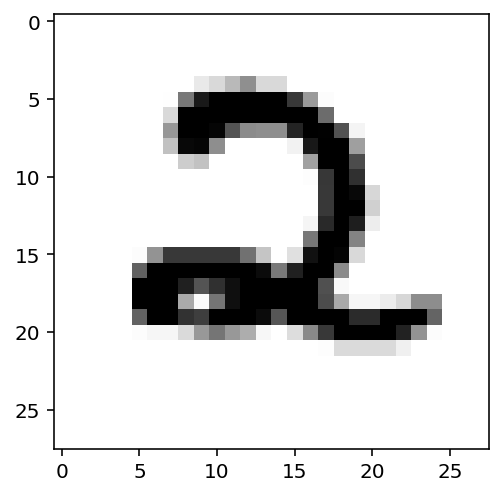

In [ ]:
# Let’s display one image from the training set
plt.imshow(images[0].numpy().squeeze(), cmap='gray_r');

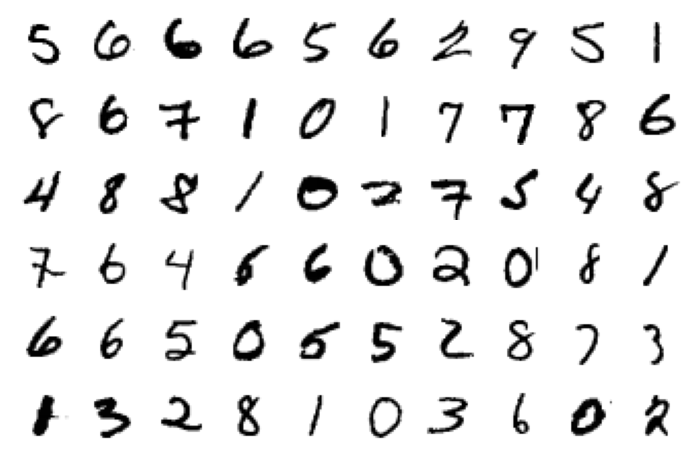

In [ ]:
# Let’s display some more images, this will give us a feel of how the dataset looks like.
figure = plt.figure()
num_of_images = 60
for index in range(1, num_of_images + 1):
    plt.subplot(6, 10, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

###**Step 3: Build The Neural Network**

We will be building the following network, as you can see it contains an input layer (the first layer), an output layer of ten neurons (or units, the circles) and two hidden layers in between.


> Indented block


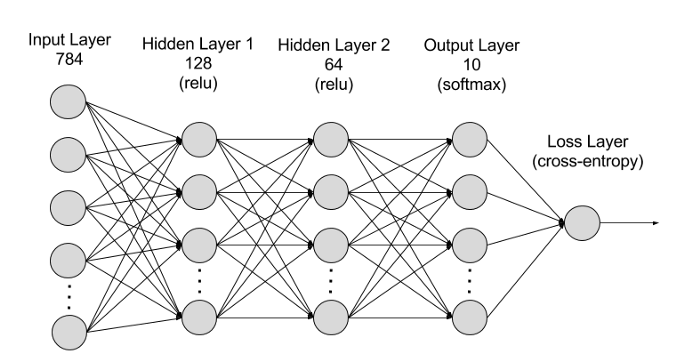

PyTorch’s torch.nn module allows us to build the neural network very simply.

In [ ]:
from torch import nn

# Layer details for the neural network
input_size = 784
hidden_sizes = [128, 64]
output_size = 10

# Build a feed-forward network
model = nn.Sequential(nn.Linear(input_size, hidden_sizes[0]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[0], hidden_sizes[1]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[1], output_size),
                      nn.LogSoftmax(dim=1))
print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): LogSoftmax(dim=1)
)


The *nn.Sequential* wraps the layers in the network. There are **linear layers** with **ReLU activation** (a simple function which allows positive values to pass through, whereas negative values are modified to zero). The output layer is a linear layer with **LogSoftmax** activation because this is a classification problem.

Also, you must be wondering why do we have 784 units in the first layer. It is because we flatten out each image before sending it inside the neural network. (28 x 28 = 784)

In [ ]:
criterion = nn.NLLLoss()
images, labels = next(iter(trainloader))
images = images.view(images.shape[0], -1)

logps = model(images)
loss = criterion(logps, labels)

###**Step 4: Adjusting Weights**

A neural network learns by iterating multiple times over the available data. The terms ***learn*** refers to the adjustment of weights of the network to minimize the loss. Let’s visualize how it works.

In [ ]:
print('Before backward pass: \n', model[0].weight.grad)

loss.backward()

print('After backward pass: \n', model[0].weight.grad)

Before backward pass: 
 None
After backward pass: 
 tensor([[-0.0005, -0.0005, -0.0005,  ..., -0.0005, -0.0005, -0.0005],
        [ 0.0063,  0.0063,  0.0063,  ...,  0.0063,  0.0063,  0.0063],
        [-0.0015, -0.0015, -0.0015,  ..., -0.0015, -0.0015, -0.0015],
        ...,
        [ 0.0010,  0.0010,  0.0010,  ...,  0.0010,  0.0010,  0.0010],
        [-0.0025, -0.0025, -0.0025,  ..., -0.0025, -0.0025, -0.0025],
        [-0.0004, -0.0004, -0.0004,  ..., -0.0004, -0.0004, -0.0004]])


Before the backward pass, the model weights are set to default **none** values. Once, we call the **backward()** function the weights are updated.

###**Step 5: Core Training Process**

This is where the actual magic happens. Your neural network iterates over the training set and updates the weights. We make use of *torch.optim* which is a module provided by PyTorch to optimize the model, perform gradient descent and update the weights by back-propagation. Thus in each **epoch** (number of times we iterate over the training set), we will be seeing a gradual decrease in training loss.

In [ ]:
from torch import optim

# Optimizers require the parameters to optimize and a learning rate
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [ ]:
print('Initial weights - ', model[0].weight)

images, labels = next(iter(trainloader))
images.resize_(64, 784)

# Clear the gradients, do this because gradients are accumulated
optimizer.zero_grad()

# Forward pass, then backward pass, then update weights
output = model(images)
loss = criterion(output, labels)
loss.backward()
print('Gradient -', model[0].weight.grad)

Initial weights -  Parameter containing:
tensor([[-0.0248, -0.0213,  0.0189,  ..., -0.0109, -0.0079, -0.0223],
        [-0.0283, -0.0218, -0.0083,  ...,  0.0300, -0.0215, -0.0326],
        [ 0.0341,  0.0160, -0.0197,  ..., -0.0096, -0.0260,  0.0056],
        ...,
        [ 0.0352,  0.0184, -0.0220,  ...,  0.0265,  0.0086,  0.0276],
        [-0.0189,  0.0316,  0.0046,  ...,  0.0080,  0.0246,  0.0012],
        [-0.0270, -0.0310,  0.0204,  ..., -0.0223,  0.0187, -0.0299]],
       requires_grad=True)
Gradient - tensor([[-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        [ 0.0034,  0.0034,  0.0034,  ...,  0.0034,  0.0034,  0.0034],
        [ 0.0002,  0.0002,  0.0002,  ...,  0.0002,  0.0002,  0.0002],
        ...,
        [ 0.0002,  0.0002,  0.0002,  ...,  0.0002,  0.0002,  0.0002],
        [ 0.0012,  0.0012,  0.0012,  ...,  0.0012,  0.0012,  0.0012],
        [-0.0033, -0.0033, -0.0033,  ..., -0.0033, -0.0033, -0.0033]])


In [ ]:
# Take an update step and few the new weights
optimizer.step()
print('Updated weights - ', model[0].weight)

Updated weights -  Parameter containing:
tensor([[-0.0248, -0.0213,  0.0189,  ..., -0.0109, -0.0079, -0.0223],
        [-0.0283, -0.0219, -0.0083,  ...,  0.0299, -0.0216, -0.0326],
        [ 0.0341,  0.0160, -0.0197,  ..., -0.0096, -0.0260,  0.0056],
        ...,
        [ 0.0352,  0.0184, -0.0220,  ...,  0.0265,  0.0086,  0.0276],
        [-0.0189,  0.0315,  0.0046,  ...,  0.0080,  0.0246,  0.0012],
        [-0.0270, -0.0309,  0.0205,  ..., -0.0223,  0.0187, -0.0299]],
       requires_grad=True)


In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
time0 = time()
epochs = 15
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        # Flatten MNIST images into a 784 long vector
        images = images.view(images.shape[0], -1)

        # Training pass
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)

        #This is where the model learns by backpropagating
        loss.backward()

        #And optimizes its weights here
        optimizer.step()

        running_loss += loss.item()
    else:
        print("Epoch {} - Training loss: {}".format(e, running_loss/len(trainloader)))
print("\nTraining Time (in minutes) =",(time()-time0)/60)

Epoch 0 - Training loss: 0.6509159879246628
Epoch 1 - Training loss: 0.290752568399347
Epoch 2 - Training loss: 0.22463747070256326
Epoch 3 - Training loss: 0.17618147675781998
Epoch 4 - Training loss: 0.14557046001193238
Epoch 5 - Training loss: 0.12360892700615214
Epoch 6 - Training loss: 0.10853058298720099
Epoch 7 - Training loss: 0.09604791809977499
Epoch 8 - Training loss: 0.08730008166436273
Epoch 9 - Training loss: 0.07789824437449323
Epoch 10 - Training loss: 0.07144186446971412
Epoch 11 - Training loss: 0.06521869366611245
Epoch 12 - Training loss: 0.060116172196276026
Epoch 13 - Training loss: 0.05579784928065445
Epoch 14 - Training loss: 0.052036790832279446

Training Time (in minutes) = 3.3616724848747253


This can take some time to execute and will vary from system to system.

###**Step 6: Testing & Evaluation**

We are nearly done with our work. The model is ready, but we have to evaluate it first. We passed an image to the trained model from the validation set that we created earlier, to see how the model works.


In [ ]:
def view_classify(img, ps):
    ''' Function for viewing an image and it's predicted classes.
    '''
    ps = ps.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(np.arange(10))
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)
    plt.tight_layout()

Predicted Digit = 3


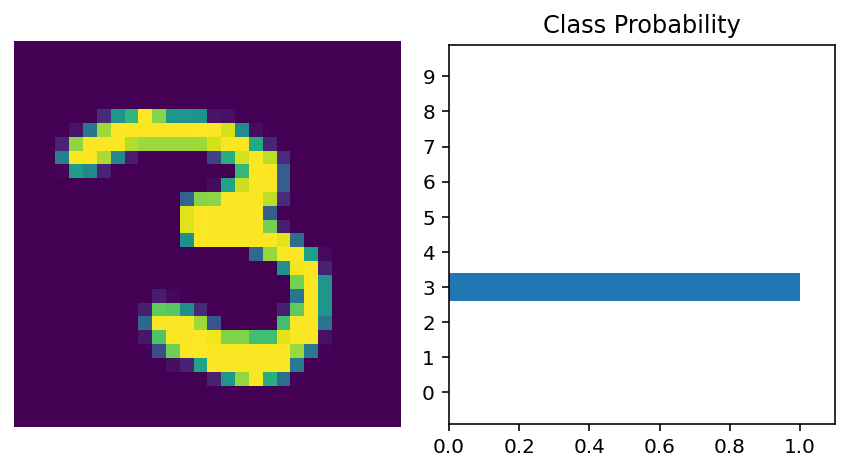

In [ ]:
images, labels = next(iter(valloader))

img = images[0].view(1, 784)
# Turn off gradients to speed up this part
with torch.no_grad():
    logps = model(img)

# Output of the network are log-probabilities, need to take exponential for probabilities
ps = torch.exp(logps)
probab = list(ps.numpy()[0])
print("Predicted Digit =", probab.index(max(probab)))
view_classify(img.view(1, 28, 28), ps)

Now we iterate through the validation set using a for loop and calculate the total number of correct predictions. This is how we can calculate the accuracy.

In [ ]:
correct_count, all_count = 0, 0
for images,labels in valloader:
  for i in range(len(labels)):
    img = images[i].view(1, 784)
    # Turn off gradients to speed up this part
    with torch.no_grad():
        logps = model(img)

    # Output of the network are log-probabilities, need to take exponential for probabilities
    ps = torch.exp(logps)
    probab = list(ps.numpy()[0])
    pred_label = probab.index(max(probab))
    true_label = labels.numpy()[i]
    if(true_label == pred_label):
      correct_count += 1
    all_count += 1

print("Number Of Images Tested =", all_count)
print("\nModel Accuracy =", (correct_count/all_count))

Number Of Images Tested = 10000

Model Accuracy = 0.9764


We got over 97.6% accuracy. That’s something to celebrate. The reason we got such a high accuracy was that our data-set was clean, had a variety of well-shuffled images and a large number of them. This made our model well prepared to recognize a large number of unseen digits.

Reference: https://towardsdatascience.com/handwritten-digit-mnist-pytorch-977b5338e627